<a href="https://colab.research.google.com/github/shoubhikchakraborty/rag/blob/main/travel_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langgraph langchain langchain-core langchain-groq requests pydantic typing_extensions

In [ ]:
import os
import re
import json
import time
import random
import math
import operator
import requests

from statistics import median
from datetime import datetime
from functools import lru_cache
from urllib.parse import quote
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import TypedDict, Annotated, List, Literal

from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END

# Loading Secrets

In [ ]:

try:
  from google.colab import userdata
except:
  userdata= None

def load_secret(key):
  if userdata is None:
    return "Userdata is None"
  try:
    value = userdata.get(key)
    if value:
      os.environ[key] = value
  except Exception as e:
    print(f"Error loading secret: {e}")



for key in ["GROQ_API_KEY", "TAVILY_API_KEY"]:
    load_secret(key)

print("GROQ key loaded:", bool(os.environ.get("GROQ_API_KEY")))
print("Tavily key loaded:", bool(os.environ.get("TAVILY_API_KEY")))

GROQ key loaded: True
Tavily key loaded: True


# Config

In [ ]:
MODEL_NAME = os.getenv("GROQ_MODEL", "openai/gpt-oss-20b")
MAX_TAVILY_SEARCH = 3
ATTRACTION_LIMIT = 8
HOTEL_LIMIT = 8
HTTP_TIMEOUT = 25
TOOL_WORKERS = 4

CONTACT_EMAIL = os.getenv("OSM_CONTACT_EMAIL", "xyz@gmail.com")
USER_AGENT = f"travel-multiagent-colab/1.0 ({CONTACT_EMAIL})"

GROQ_MODELS = [
    "openai/gpt-oss-20b",
    "openai/gpt-oss-120b",
    "qwen/qwen3-32b",
]

MODEL_INDEX= 0

def get_llm(model_name=None, temperature= 0.1):
  llm= ChatGroq(
    model= model_name,
    temperature= temperature,
    api_key= os.getenv("GROQ_API_KEY")
  )
  return llm

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


"""The WEATHER_CODE_MAP is a Python dictionary that maps numeric codes to human-readable weather descriptions based on the WMO
(World Meteorological Organization) Code Table 4677."""

WEATHER_CODE_MAP = {
    0: "Clear Sky",

    1: "Mainly Clear",
    2: "Partly Cloudy",
    3: "Overcast",

    45: "Fog",
    48: "Depositing Rime Fog",

    51: "Light Drizzle",
    53: "Moderate Drizzle",
    55: "Dense Drizzle",

    56: "Light Freezing Drizzle",
    57: "Dense Freezing Drizzle",

    61: "Slight Rain",
    63: "Moderate Rain",
    65: "Heavy Rain",

    66: "Light Freezing Rain",
    67: "Heavy Freezing Rain",

    71: "Slight Snowfall",
    73: "Moderate Snowfall",
    75: "Heavy Snowfall",

    77: "Snow Grains",

    80: "Slight Rain Showers",
    81: "Moderate Rain Showers",
    82: "Heavy Rain Showers",

    85: "Slight Snow Showers",
    86: "Heavy Snow Showers",

    95: "Thunderstorm",

    96: "Thunderstorm with Slight Hail",
    99: "Thunderstorm with Heavy Hail"
}

In [ ]:
import random

def is_rate_limit_error(exc):
    text = str(exc).lower()

    return (
        "ratelimit" in text
        or "rate limit" in text
        or "429" in text
        or "too many requests" in text
        or "tokens per minute" in text
        or "requests per minute" in text
    )


def invoke_llm(prompt, temperature=0.1, max_retries=5):
    """
    Invoke Groq with:
    1. Retry
    2. Exponential backoff
    3. Model rotation
    4. Small random jitter
    """

    last_error = None

    for attempt in range(max_retries):

        # Rotate model on every retry
        model_name = GROQ_MODELS[attempt % len(GROQ_MODELS)]

        try:
            llm_instance = get_llm(
                model_name=model_name,
                temperature=temperature
            )

            print(
                f"LLM attempt {attempt + 1}/{max_retries} "
                f"using {model_name}"
            )

            response = llm_instance.invoke([
                HumanMessage(content=prompt)
            ])

            result = response.content

            time.sleep(1.0)

            return result

        except Exception as e:

            last_error = e

            if not is_rate_limit_error(e):
                raise

            wait_time = min(
                30,
                (2 ** attempt) + random.uniform(0.5, 2.0)
            )

            print(
                f"Rate limit from {model_name}. "
                f"Waiting {wait_time:.1f}s..."
            )

            time.sleep(wait_time)

    raise RuntimeError(
        f"All Groq model attempts failed. "
        f"Last error: {last_error}"
    )

# Helper Functions

In [ ]:
def pretty(obj):
  return json.dumps(obj, indent=2, ensure_ascii= False)

def safe_request(method, url, params= None, data= None, headers= None, json_body= None, timeout= HTTP_TIMEOUT, retries= 1):
  headers= headers or {}
  if "User-Agent" not in headers:
    headers["User-Agent"]= USER_AGENT

  last_error = None
  for attempt in range(retries + 1):
    try:
      r= SESSION.request(method= method,
                         url= url,
                         params= params,
                         data= data,
                         headers= headers,
                         json= json_body,
                         timeout= timeout)
      r.raise_for_status()
      if r.text.strip():
        try:
          return {"ok": True, "data": r.json()}
        except:
          return {"ok": True, "data": r.text}
      return {"ok": True, "data": {}}
    except Exception as e:
      last_error= str(e)
      if attempt < retries:
        time.sleep(1.2 * (attempt + 1))

  return {"ok": False, "error": last_error}


def compact_text(text, limit= 700):
    if not text:
      return text
    text= str(text).strip()
    return text[:limit] + ("..." if len(text) > limit else "")



def safe_trip_days(start_date: str, end_date: str) -> int:
  try:
    d1= datetime.fromisoformat(start_date)
    d2= datetime.fromisoformat(end_date)
    days= (d2 - d1).days
    return max(days, 1)
  except:
    return 3

def haversine_km(lat1, lon1, lat2, lon2):
  r= 6371
  p1, p2= math.radians(lat1), math.radians(lat2)
  dphi= math.radians(lat2 - lat1)
  dlambda= math.radians(lon2 - lon1)
  a= math.sin(dphi / 2)**2 + math.cos(p1) * math.cos(p2) * math.sin(dlambda / 2)**2
  return 2 * r * math.asin(math.sqrt(a))

def requested_tasks(plan: dict):
  tasks= plan.get("tasks") or [
      "destination_research",
      "itinerary_planning",
      "accommodation_planning",
      "transport_booking"
  ]
  return set(tasks)

In [ ]:
def _currency_regexes(currency: str = "USD"):
    currency = (currency or "USD").upper()

    regex_map = {
        "USD": [
            r"\$\s?(\d+(?:[.,]\d+)?)",
            r"USD\s?(\d+(?:[.,]\d+)?)"
        ],
        "EUR": [
            r"€\s?(\d+(?:[.,]\d+)?)",
            r"EUR\s?(\d+(?:[.,]\d+)?)"
        ],
        "GBP": [
            r"£\s?(\d+(?:[.,]\d+)?)",
            r"GBP\s?(\d+(?:[.,]\d+)?)"
        ],
        "INR": [
            r"₹\s?(\d+(?:[.,]\d+)?)",
            r"INR\s?(\d+(?:[.,]\d+)?)",
            r"Rs\.?\s?(\d+(?:[.,]\d+)?)"
        ],
        "AED": [
            r"AED\s?(\d+(?:[.,]\d+)?)",
            r"د\.إ\s?(\d+(?:[.,]\d+)?)"
        ],
        "SGD": [
            r"SGD\s?(\d+(?:[.,]\d+)?)",
            r"S\$\s?(\d+(?:[.,]\d+)?)"
        ],
        "AUD": [
            r"AUD\s?(\d+(?:[.,]\d+)?)",
            r"A\$\s?(\d+(?:[.,]\d+)?)"
        ],
        "CAD": [
            r"CAD\s?(\d+(?:[.,]\d+)?)",
            r"C\$\s?(\d+(?:[.,]\d+)?)"
        ],
        "JPY": [
            r"¥\s?(\d+(?:[.,]\d+)?)",
            r"JPY\s?(\d+(?:[.,]\d+)?)"
        ]
    }

    return regex_map.get(currency, [rf"{currency}\s?(\d+(?:[.,]\d+)?)"])


def _extract_fare_values_from_tavily(search_payload: dict, currency: str = "USD"):
    if not isinstance(search_payload, dict):
        return []

    texts = []

    answer = search_payload.get("answer")
    if answer:
        texts.append(answer)

    for item in search_payload.get("results", []):
        title = item.get("title", "")
        content = item.get("content", "")
        texts.append(f"{title} {content}")

    patterns = _currency_regexes(currency)
    values = []

    for text in texts:
        text = (text or "").replace(",", "")
        for pattern in patterns:
            for match in re.finditer(pattern, text, flags=re.IGNORECASE):
                try:
                    val = float(match.group(1))
                    if 3 <= val <= 2000:
                        values.append(val)
                except:
                    pass

    values = sorted(values)

    if len(values) >= 4:
        m = median(values)
        values = [v for v in values if 0.35 * m <= v <= 2.5 * m]

    return sorted(values)


# Searching

In [ ]:
@lru_cache(maxsize= 256)
def geocode_place(query: str):
  query= (query or "").strip()
  if not query:
    return {"ok": False, "error": "Empty location query"}

  url = "https://nominatim.openstreetmap.org/search"
  params = {"q": query,"format": "jsonv2","limit":1}
  res = safe_request("GET", url, params= params)
  if not res["ok"]:
    return {"ok": False, "error": res["error"]}

  items= res["data"]
  if not items:
    return {"ok": False, "error": f"No location found for: {query}"}
  item= items[0]

  return {"ok": True,
          "query": query,
          "display_name": item.get("display_name"),
          "lat": float(item.get("lat")),
          "lon": float(item.get("lon")),
          "boundingbox": item.get("boundingbox", [])}


In [ ]:
geocode_place("burdwan")

{'ok': True,
 'query': 'burdwan',
 'display_name': 'Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, India',
 'lat': 23.2495714,
 'lon': 87.8681751,
 'boundingbox': ['23.2089953', '23.2904778', '87.8201045', '87.9241185']}

In [ ]:
@lru_cache(maxsize= 256)
def wikipedia_summary(title: str):
  title= (title or "").strip()
  if not title:
    return {"ok": False, "error": "Empty title"}

  url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{quote(title)}"

  res = safe_request("GET", url)
  if not res["ok"]:
    return {"ok": False, "error": res["error"]}

  data= res["data"]


  return {"ok": True,
          "title": data.get("title", title),
          "summary": data.get("extract"),
          "url": data.get("content_urls", {}).get("desktop", {}).get("page")
          }



In [ ]:
wikipedia_summary("Fifa world cup")

{'ok': True,
 'title': 'FIFA World Cup',
 'summary': "The FIFA World Cup is an international association football competition among the senior men's national teams of the members of the Fédération Internationale de Football Association (FIFA), the sport's global governing body. The tournament has been held every four years since the inaugural tournament in 1930, with the exception of 1942 and 1946 during and shortly after World War II. The reigning champion is Spain, who won their second title at the 23rd edition of the competition, the 2026 World Cup, by defeating the holders, Argentina.",
 'url': 'https://en.wikipedia.org/wiki/FIFA_World_Cup'}

In [ ]:
@lru_cache(maxsize= 256)
def get_weather_data(city: str):
  geo= geocode_place(city)
  if not geo["ok"]:
    return {"ok": False, "error": geo["error"]}

  url= "https://api.open-meteo.com/v1/forecast"
  params= {
      "latitude": geo["lat"],
      "longitude": geo["lon"],
      "current": "temperature_2m,wind_speed_10m,weather_code,relative_humidity_2m",
      "daily": "weather_code,temperature_2m_max,temperature_2m_min,precipitation_probability_max,sunrise,sunset",
      "timezone": "auto",
      "forecast_days": 5
  }
  res = safe_request("GET", url, params= params)
  if not res["ok"]:
    return {"ok": False, "error": res["error"]}

  data= res["data"]
  current= data.get("current", {})
  daily= data.get("daily", {})

  forecast = []
  dates= daily.get("time", [])
  max_t= daily.get("temperature_2m_max", [])
  min_t= daily.get("temperature_2m_min", [])
  codes= daily.get("weather_code", [])
  rain= daily.get("precipitation_probability_max", [])
  sunrise= daily.get("sunrise", [])
  sunset= daily.get("sunset", [])

  for i in range(min(5, len(dates))):
    forecast.append({
        "date": dates[i],
        "condition": WEATHER_CODE_MAP.get(codes[i], str(codes[i])) if i < len(codes) else None,
        "temp_max_c": max_t[i] if i < len(max_t) else None,
        "temp_min_c": min_t[i] if i < len(min_t) else None,
        "precipitation_probability_max": rain[i] if i < len(rain) else None,
        "sunrise": sunrise[i] if i < len(sunrise) else None,
        "sunset": sunset[i] if i < len(sunset) else None
    })

  return{
      "ok": True,
      "city": city,
      "resolved_location":geo["display_name"],
      "current": {
          "temperature_c": current.get("temperature_2m"),
          "wind_speed_10m": current.get("wind_speed_10m"),
          "condition": WEATHER_CODE_MAP.get(current.get("weather_code"), str(current.get("weather_code"))),
          "humidity": current.get("relative_humidity_2m")
      },
      "forecast": forecast
  }

In [ ]:
get_weather_data("Burdwan")

{'ok': True,
 'city': 'Burdwan',
 'resolved_location': 'Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, India',
 'current': {'temperature_c': 30.8,
  'wind_speed_10m': 2.0,
  'condition': 'Mainly Clear',
  'humidity': 74},
 'forecast': [{'date': '2026-09-27',
   'condition': 'Dense Drizzle',
   'temp_max_c': 31.0,
   'temp_min_c': 24.7,
   'precipitation_probability_max': 70,
   'sunrise': '2026-09-27T05:28',
   'sunset': '2026-09-27T17:30'},
  {'date': '2026-09-28',
   'condition': 'Mainly Clear',
   'temp_max_c': 31.8,
   'temp_min_c': 25.1,
   'precipitation_probability_max': 6,
   'sunrise': '2026-09-28T05:29',
   'sunset': '2026-09-28T17:29'},
  {'date': '2026-09-29',
   'condition': 'Clear Sky',
   'temp_max_c': 32.0,
   'temp_min_c': 24.6,
   'precipitation_probability_max': 4,
   'sunrise': '2026-09-29T05:29',
   'sunset': '2026-09-29T17:28'},
  {'date': '2026-09-30',
   'condition': 'Overcast',
   'temp_max_c': 31.8,
   'temp_min_c': 24.5,
   'precipitation_probability_m

In [ ]:
def overpass_query(query: str):
  url= "https://overpass-api.de/api/interpreter"
  return safe_request("GET", url, data= {"data": query}, timeout= 50)

@lru_cache(maxsize= 256)
def search_attraction_data(city: str, limit: int = ATTRACTION_LIMIT):

    # ---------------------------------------
    # 1. Geocode the city
    # ---------------------------------------
    geo = geocode_place(city)

    if not geo["ok"]:
        return {
            "ok": False,
            "error": geo["error"]
        }

    lat, lon = geo["lat"], geo["lon"]

    # ---------------------------------------
    # 2. Build Overpass query
    # ---------------------------------------
    query = f"""
    [out:json][timeout:45];

    (
        /* Tourist attractions */
        node["tourism"~"attraction|museum|gallery|viewpoint|zoo|theme_park|artwork|aquarium"]
            (around:8000,{lat},{lon});

        way["tourism"~"attraction|museum|gallery|viewpoint|zoo|theme_park|artwork|aquarium"]
            (around:8000,{lat},{lon});

        /* Important historical attractions */
        node["historic"~"monument|castle|fort|ruins|archaeological_site|memorial|city_gate|manor"]
            (around:8000,{lat},{lon});

        way["historic"~"monument|castle|fort|ruins|archaeological_site|memorial|city_gate|manor"]
            (around:8000,{lat},{lon});
    );

    out center tags;
    """

    # ---------------------------------------
    # 3. Execute Overpass query
    # ---------------------------------------
    res = overpass_query(query)

    if not res["ok"]:
        return {
            "ok": False,
            "error": res["error"]
        }

    # ---------------------------------------
    # 4. Process results
    # ---------------------------------------
    items = []
    seen = set()

    for el in res["data"].get("elements", []):

        tags = el.get("tags", {})

        # Get attraction name
        name = tags.get("name")

        # Ignore unnamed places
        if not name:
            continue

        # ---------------------------------------
        # Determine attraction type
        # ---------------------------------------
        kind = (
            tags.get("tourism")
            or tags.get("historic")
            or "poi"
        )

        # ---------------------------------------
        # Remove duplicates
        # ---------------------------------------
        key = (
            name.strip().lower(),
            kind.strip().lower()
        )

        if key in seen:
            continue

        seen.add(key)

        # ---------------------------------------
        # Get coordinates
        # ---------------------------------------
        lat_value = el.get("lat")

        lon_value = el.get("lon")

        # Ways don't have direct lat/lon.
        # Use their center coordinates.
        if lat_value is None:
            lat_value = el.get("center", {}).get("lat")

        if lon_value is None:
            lon_value = el.get("center", {}).get("lon")

        # ---------------------------------------
        # Add attraction
        # ---------------------------------------
        items.append({
            "name": name.strip(),
            "kind": kind,
            "lat": lat_value,
            "lon": lon_value
        })

    # ---------------------------------------
    # 5. Return final response
    # ---------------------------------------
    return {
        "ok": True,
        "city": city,
        "resolved_location": geo["display_name"],
        "count": len(items[:limit]),
        "items": items[:limit]
    }

In [ ]:
search_attraction_data("Burdwan")

{'ok': True,
 'city': 'Burdwan',
 'resolved_location': 'Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, India',
 'count': 8,
 'items': [{'name': 'Swami Vivekanada Statue',
   'kind': 'memorial',
   'lat': 23.2370165,
   'lon': 87.8617326},
  {'name': 'khudiram Statue',
   'kind': 'artwork',
   'lat': 23.2374138,
   'lon': 87.8656331},
  {'name': 'Renaissance Gate No 3',
   'kind': 'attraction',
   'lat': 23.2663552,
   'lon': 87.8266013},
  {'name': 'Nawab Bari',
   'kind': 'monument',
   'lat': 23.2251398,
   'lon': 87.8539722},
  {'name': 'Bardhaman Rajbati',
   'kind': 'castle',
   'lat': 23.2392114,
   'lon': 87.851659},
  {'name': 'Bardhaman Zoological Park',
   'kind': 'zoo',
   'lat': 23.2546585,
   'lon': 87.8512512},
  {'name': 'Netaji Subhash Chandra Bose',
   'kind': 'memorial',
   'lat': 23.240073,
   'lon': 87.8684346},
  {'name': 'Hool Divas Sidhu Kanhu Sculpture',
   'kind': 'memorial',
   'lat': 23.2399217,
   'lon': 87.8687081}]}

In [ ]:
@lru_cache(maxsize= 256)
def tavily_search(query: str, max_results: int = MAX_TAVILY_SEARCH, topic: str= "general"):

  api_key= os.getenv("TAVILY_API_KEY")

  if not api_key:
    return {"ok": False, "error": "Tavily API key not found", "answer": None, "results": []}

  url= "https://api.tavily.com/search"
  payload= {
      "api_key": api_key,
      "query": query,
      "search_depth": "advanced",
      "topic": topic,
      "include_answer": True,
      "include_raw_content": False,
      "max_results": max_results

  }
  res = safe_request("POST", url, json_body= payload)

  if not res["ok"]:
    return {"ok": False, "error": res["error"], "query": query, "answer": None, "results": []}

  data= res["data"]
  cleaned= []
  for item in data.get("results", []):
    cleaned.append({
        "title": item.get("title"),
        "url": item.get("url"),
        "content": compact_text(item.get("content", ""), 400)
    })
  return {
      "ok": True,
      "query": query,
      "answer": compact_text(data.get("answer", ""), 700),
      "results": cleaned
  }

In [ ]:
@lru_cache(maxsize= 256)
def search_events_news_data(city: str, start_date: str = "", end_date: str = ""):
  query= f"""
  Upcoming events, festivals, exhibitions, tourism updates, airport updates and recent travel related news in {city} between
  {start_date} and {end_date}. Prefer official tourism pages, reliable travel pages and reliable news paper.
  """
  return tavily_search(query, MAX_TAVILY_SEARCH, "general")

In [ ]:
search_events_news_data("Kolkata", start_date= '2026-08-20', end_date= '2026-09-15')

{'ok': True,
 'query': '\n  Upcoming events, festivals, exhibitions, tourism updates, airport updates and recent travel related news in Kolkata between\n  2026-08-20 and 2026-09-15. Prefer official tourism pages, reliable travel pages and reliable news paper.\n  ',
 'answer': 'In September 2026, Kolkata hosts Ananda Sandhya, Matri Rupen, and The Last Hilsa of the Monsoon. These events occur in late September, primarily at Mahajati Sadan, Uttam Mancha, and That Red House.',
 'results': [{'title': 'Festivals Events in Kolkata, WB',
   'url': 'https://happeningnext.com/kolkata/festivals',
   'content': '### Matri Rupen Uttam Mancha: Kolkata 30 Sep 2026\n\n### Immersion Cruise 2026 Vivada Cruise 21 Oct 2026\n\nWORKSHOPS INR 1,580 TO 3,150\n\n### Emami Art Experimental Film Festival 2026 Emami Art - A Space for Contemporary Art in Kolkata 24 Sep 2026\n\nEXHIBITIONS FREE\n\n### दीपावली Budho Balaji Darwar Gol Mandir,budho Shiv Talla Mandir 8 Nov 2026\n\n### Goddess in Transit: A Photo Walk J

# Routing, hotels, airport, cab estimates

In [ ]:
def osrm_route_by_coords(origin_name, origin_lat, origin_lon, destination_name, destination_lat, destination_lon, profile= 'driving'):
    profile = profile if profile in ["walking", "cycling", "driving"] else "driving"
    url = f"http://router.project-osrm.org/route/v1/{profile}/{origin_lon},{origin_lat};{destination_lon},{destination_lat}"
    params = {"overview": "false", "steps": "true"}
    res = safe_request("GET", url, params=params)

    if not res["ok"]:
        return {"ok": False, "error": res["error"]}

    routes = res["data"]["routes"]
    if not routes:
        return {"ok": False, "error": "No route found"}

    route = routes[0]
    steps = []
    legs= route.get("legs", [])
    if legs:
      for s in legs[0].get("steps", [])[:8]:
        steps.append({
            "instruction_type": s.get("maneuver", {}).get("type"),
            "road_name": s.get("name"),
            "distance_m": round(s.get("distance", 0),1),
            "duration_min": round(s.get("duration", 0) / 60, 1)
        })

    return {
        "ok": True,
        "origin_name": origin_name,
        "destination_name": destination_name,
        "profile": profile,
        "distance_km": round(route.get("distance", 0) / 1000, 2),
        "duration_min": round(route.get("duration", 0) / 60, 1),
        "steps": steps
    }

@lru_cache(maxsize= 256)
def osm_route(origin: str, destination: str, profile : str = 'driving'):
  o = geocode_place(origin)
  d = geocode_place(destination)

  if not o["ok"]:
    return {"ok": False, "error": o["error"]}
  if not d["ok"]:
    return {"ok": False, "error": d["error"]}


  return osrm_route_by_coords(o["display_name"], o["lat"], o["lon"],
                              d["display_name"], d["lat"], d["lon"],
                              profile= profile)

In [ ]:
osm_route("burdwan station", "burdwan medical college hospital")

{'ok': True,
 'origin_name': 'WBSEDCL 33KV Electric Sub Station, Renaissance Township, Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, India',
 'destination_name': 'Burdwan Medical College And Hospital, Aftab Avenue, Golapbag, Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, 713104, India',
 'profile': 'driving',
 'distance_km': 13.26,
 'duration_min': 24.9,
 'steps': [{'instruction_type': 'depart',
   'road_name': '',
   'distance_m': 251.4,
   'duration_min': 0.6},
  {'instruction_type': 'turn',
   'road_name': '',
   'distance_m': 812.1,
   'duration_min': 2.0},
  {'instruction_type': 'end of road',
   'road_name': 'Grand Trunk Road',
   'distance_m': 1544.3,
   'duration_min': 3.9},
  {'instruction_type': 'turn',
   'road_name': '',
   'distance_m': 322.4,
   'duration_min': 0.8},
  {'instruction_type': 'merge',
   'road_name': 'Grand Trunk Road',
   'distance_m': 49,
   'duration_min': 0.2},
  {'instruction_type': 'turn',
   'road_name': '',
   'distance_m': 1055.1,
   

In [ ]:
@lru_cache(maxsize=256)
def search_hotels_osm(city: str, limit: int = HOTEL_LIMIT):
  geo = geocode_place(city)

  if not geo["ok"]:
    return {"ok": False,"error": geo["error"]}

  lat, lon = geo["lat"], geo["lon"]
  query= f"""
  [out:json][timeout:25];
  (
    node["tourism"~"hotel|hostel|guest_house|motel|apartment"](around:7000,{lat},{lon});
    way["tourism"~"hotel|hostel|guest_house|motel|apartment"](around:7000,{lat},{lon});
  );
  out center tags;
  """

  res = overpass_query(query)

  if not res["ok"]:
    return {"ok": False,"error": res["error"]}

  hotels = []
  seen = set()

  for el in res["data"].get("elements", []):
    tags = el.get("tags", {})
    name = tags.get("name")
    if not name:
      continue
    key= name.lower()
    if key in seen:
      continue
    seen.add(key)
    hotels.append({
        "name": name,
        "type": tags.get("tourism"),
        "stars": tags.get("stars"),
        "address": ", ".join([v for v in [
            tags.get("addr:housenumber"),
            tags.get("addr:street"),
            tags.get("addr:city")
        ] if v ]) or None,
        "lat": el.get("lat") or el.get("center", {}).get("lat"),
        "lon": el.get("lon") or el.get("center", {}).get("lon")
    })
  return {
      "ok": True,
      "city": city,
      "resolved_location": geo["display_name"],
      "hotels": hotels[:limit]
  }

In [ ]:
@lru_cache(maxsize=128)
def airport_candidates(city: str, limit: int = 3):
  geo= geocode_place(city)

  if not geo["ok"]:
    return {"ok": False,"error": geo["error"]}

  lat, lon = geo["lat"], geo["lon"]
  query= f"""
  [out:json][timeout:50];
  (
    node["aeroway"="aerodrome"](around:90000,{lat},{lon});
    way["aeroway"="aerodrome"](around:90000,{lat},{lon});
    relation["aeroway"="aerodrome"](around:90000,{lat},{lon});
  );
  out center tags;
  """

  res= overpass_query(query)

  if not res["ok"]:
    return {"ok": False,"error": res["error"]}

  airports= []
  for el in res['data'].get('elements', []):
    tags= el.get('tags', {})
    name= tags.get('name')
    if not name:
      continue
    if tags.get("military") == 'yes':
      continue

    a_lat = el.get("lat") or el.get("center", {}).get("lat")
    a_lon = el.get("lon") or el.get("center", {}).get("lon")

    if a_lat is None or a_lon is None:
      continue

    dist = haversine_km(lat, lon, a_lat, a_lon)

    airports.append({
        "name": name,
        "iata": tags.get("iata"),
        "icao": tags.get("icao"),
        "lat": a_lat,
        "lon": a_lon,
        "distance_from_city_km": round(dist, 1)
    })
  airports = sorted(airports, key=lambda x: (0 if x.get("iata") else 1, x["distance_from_city_km"]))
  return {
      "ok": True,
      "city": city,
      "city_center": {
          "name": geo["display_name"],
          "lat": geo["lat"],
          "lon": geo["lon"]
      },
      "airports": airports[:limit]
}




In [ ]:
airport_candidates("burdwan")

{'ok': True,
 'city': 'burdwan',
 'city_center': {'name': 'Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, India',
  'lat': 23.2495714,
  'lon': 87.8681751},
 'airports': [{'name': 'Kazi Nazrul Islam Airport',
   'iata': 'RDP',
   'icao': 'VEDG',
   'lat': 23.6246022,
   'lon': 87.2421474,
   'distance_from_city_km': 76.3},
  {'name': 'Netaji Subhash Chandra Bose International Airport',
   'iata': 'CCU',
   'icao': 'VECC',
   'lat': 22.6563647,
   'lon': 88.4448077,
   'distance_from_city_km': 88.5},
  {'name': 'Arjan Singh Air Force Station',
   'iata': None,
   'icao': 'VEPH',
   'lat': 23.4734403,
   'lon': 87.4320276,
   'distance_from_city_km': 51.0}]}

In [ ]:
def estimate_cab_airport_to_city(city: str, currency: str = "INR", fare_search_payload: dict = None):
  airports= airport_candidates(city)

  if not airports["ok"]:
    return {"ok": False, "error": airports["error"]}

  city_center= airports["city_center"]
  airport_list= airports.get("airports", [])

  if not airport_list:
    fallback_route= osm_route(f"{city} airport", f"{city} city center", "driving")
    if not fallback_route["ok"]:
      return {"ok": False, "error": "Could not find airport candidates or routes"}
    route= fallback_route
    pickup_name= f"{city} airport"

  else:
    best= airport_list[0]
    pickup_name = best["name"]
    route= osrm_route_by_coords(
        pickup_name, best["lat"], best["lon"],
        city_center["name"], city_center["lat"], city_center["lon"],
        profile= "driving"
    )

  if not route["ok"]:
    return route

  distance_km= route["distance_km"]
  duration_min= route["duration_min"]

  if fare_search_payload is None and os.getenv("TAVILY_API_KEY"):
    fare_query= f"""
    Approx one-way cab fare from {pickup_name} to {city} city center. Prefer Uber, Ola, Rapido, airport taxi pages,
    local fare taxi guides and official airport transport pages. Include typical price range.
    """
    fare_search_payload= tavily_search(fare_query, max_results= 5, topic= "general")

    web_values= _extract_fare_values_from_tavily(fare_search_payload or {}, currency= currency)

    if web_values:
      est_min= round(min(web_values), 2)
      est_max= round(max(web_values), 2)
      est_median= round(median(web_values), 2)

      return {
          "ok": True,
          "pickup": pickup_name,
          "dropoff": city_center['name'],
          "distance_km": distance_km,
          "duration_min": duration_min,
          "estimated_fare_range": {
              "min": est_min,
              "max": est_max,
              "median": est_median,
              "currency": currency
          },
          "source": "tavily_provider_references",
          "matched_price_points": web_values,
          "note": "Approximate fare inferred from Tavily results. Not a live in-app quote",
          "web_references": fare_search_payload
      }

    base_fare= 3.5
    per_km= 1.4
    per_ride= 0.30

    estimate= base_fare + (distance_km * per_km) + (duration_min * per_ride)
    low= round(estimate *0.9, 2)
    high= round(estimate *1.25, 2)

    return {
          "ok": True,
          "pickup": pickup_name,
          "dropoff": city_center['name'],
          "distance_km": distance_km,
          "duration_min": duration_min,
          "estimated_fare_range": {
              "min": low,
              "max": high,
              "currency": currency
          },
          "source": "distance_time_fallback",
          "pricing_assumptions": {
              "base_fare": base_fare,
              "per_km": per_km,
              "per_ride": per_ride
          },
          "note": "Tavily did not return usable fare mentions, so a route-based fallback is used",
          "web_references": fare_search_payload
      }

In [ ]:
estimate_cab_airport_to_city("Burdwan")

{'ok': True,
 'pickup': 'Kazi Nazrul Islam Airport',
 'dropoff': 'Bardhaman, Burdwan - I, Purba Bardhaman, West Bengal, India',
 'distance_km': 82.25,
 'duration_min': 66.9,
 'estimated_fare_range': {'min': 464.0,
  'max': 1774.0,
  'median': 1315.0,
  'currency': 'INR'},
 'source': 'tavily_provider_references',
 'matched_price_points': [464.0,
  477.0,
  500.0,
  1075.0,
  1291.0,
  1339.0,
  1597.0,
  1660.0,
  1660.0,
  1774.0],
 'note': 'Approximate fare inferred from Tavily results. Not a live in-app quote',
 'web_references': {'ok': True,
  'query': '\n    Approx one-way cab fare from Kazi Nazrul Islam Airport to Burdwan city center. Prefer Uber, Ola, Rapido, airport taxi pages,\n    local fare taxi guides and official airport transport pages. Include typical price range.\n    ',
  'answer': 'The typical one-way cab fare from Kazi Nazrul Islam Airport to Burdwan city center is around ₹1774 to ₹2093. Uber Intercity offers a one-way fare from Kolkata Airport to Burdwan-I for approx

# Parallel data bundle fetchers

In [ ]:
def fetch_destination_bundle(city: str, start_date: str = "", end_date: str = ""):
  bundle= {'city': city}

  with ThreadPoolExecutor(max_workers= 4) as ex:
    futures= {
        "geo": ex.submit(geocode_place, city),
        "wiki": ex.submit(wikipedia_summary, city),
        "weather": ex.submit(get_weather_data, city),
        "attractions": ex.submit(search_attraction_data, city, ATTRACTION_LIMIT)
    }

    if os.getenv("TAVILY_API_KEY"):
      futures["events_news"] = ex.submit(search_events_news_data, city, start_date, end_date)

    for name, fut in futures.items():
      try:
        bundle[name] = fut.result()
      except Exception as e:
        bundle[name] = {"ok": False, "error": str(e)}

  return bundle

In [ ]:
fetch_destination_bundle("Hyderabad", start_date= '2026-09-12', end_date= '2026-09-14')

{'city': 'Hyderabad',
 'geo': {'ok': True,
  'query': 'Hyderabad',
  'display_name': 'Hyderabad, Bahadurpura mandal, Hyderabad, Telangana, India',
  'lat': 17.360589,
  'lon': 78.4740613,
  'boundingbox': ['17.2916377', '17.5608321', '78.2387067', '78.6223912']},
 'wiki': {'ok': True,
  'title': 'Hyderabad',
  'summary': "Hyderabad is the capital and largest city of the Indian state of Telangana. It occupies 650\xa0km2 (250\xa0sq\xa0mi) on the Deccan Plateau along the banks of the Musi River, in the northern part of Southern India. With an average altitude of 536\xa0m (1,759\xa0ft), much of Hyderabad is situated on hilly terrain around artificial lakes, including the Hussain Sagar lake, predating the city's founding, in the north of the city centre. According to the 2011 census of India, Hyderabad is the fourth-most populous city in India, with a population of 6.9 million residents within the city limits and 9.7 million residents in the metropolitan region, making it the sixth-most pop

In [ ]:
def fetch_accommodation_bundle(city: str, checkin_date: str= "", checkout_date: str= "", adults: int= 1, budget: str = 'mid-range'):
  bundle= {
      'city': city,
      'checkin_date': checkin_date,
      'checkout_date': checkout_date,
      'adults': adults,
      'budget': budget
    }

  with ThreadPoolExecutor(max_workers= 4) as ex:
    futures= {
        "osm_hotels": ex.submit(search_hotels_osm, city, HOTEL_LIMIT)
    }
    if os.getenv("TAVILY_API_KEY"):
      query= f"""
      Best areas and {budget} hotel options in {city} for {adults} adults from {checkin_date} to {checkout_date}. Prefer official hotel sites and
      reputable travel pages. Include price hints if visible.
      """
      futures['web_refs'] = ex.submit(tavily_search, query, MAX_TAVILY_SEARCH, "general")

    for name, fut in futures.items():
      try:
        bundle[name] = fut.result()
      except Exception as e:
        bundle[name] = {"ok": False, "error": str(e)}

  return bundle

In [ ]:
fetch_accommodation_bundle('hyderabad', checkin_date='2026-09-11', checkout_date='2026-09-14', adults= 2, budget= 'budget hotels')

{'city': 'hyderabad',
 'checkin_date': '2026-09-11',
 'checkout_date': '2026-09-14',
 'adults': 2,
 'budget': 'budget hotels',
 'osm_hotels': {'ok': True,
  'city': 'hyderabad',
  'resolved_location': 'Hyderabad, Bahadurpura mandal, Hyderabad, Telangana, India',
  'hotels': [{'name': 'Taj Banjara',
    'type': 'hotel',
    'stars': None,
    'address': None,
    'lat': 17.4096457,
    'lon': 78.4488565},
   {'name': 'Amrutha Castle',
    'type': 'hotel',
    'stars': None,
    'address': None,
    'lat': 17.4075442,
    'lon': 78.4688643},
   {'name': 'Hotel Golkonda',
    'type': 'hotel',
    'stars': None,
    'address': None,
    'lat': 17.404432,
    'lon': 78.4536723},
   {'name': 'Taj Mahal',
    'type': 'hotel',
    'stars': None,
    'address': None,
    'lat': 17.3994045,
    'lon': 78.4925404},
   {'name': 'Green Casserole',
    'type': 'hotel',
    'stars': None,
    'address': None,
    'lat': 17.3937827,
    'lon': 78.4704939},
   {'name': "Ohri's Baseraa Inn",
    'type':

In [ ]:
def fetch_transport_bundle(origin: str, destination: str, departure_date: str= "" ,currency: str = 'USD', adults: int= 1):
  bundle= {
      'origin': origin,
      'destination': destination,
      'departure_date': departure_date,
      'adults': adults,
      'currency': currency
  }

  with ThreadPoolExecutor(max_workers= 4) as ex:
    futures= {}

    if os.getenv('TAVILY_API_KEY'):
      flight_q= f"""
      Flight options from {origin} to {destination} on {departure_date} for {adults} adult(s). Prefer airline websites, Google flights references, Skyscanner,
      Kayak or Expedia pages. Include nonstop/direct options and price indications if visible.
      """

      local_transport_q= f"""
      Best local transport options, transit passes, airport transfer options, and tourist transport tips in {destination}.
      Prefer official transit pages, airport pages and reliable travel guides.
      """

      taxi_q= f"""
      Approx one-way cab fare from airport to city center in {destination}. Prefer Uber, Ola, Rapido, airport taxi pages,
      local fare taxi guides and official airport transport pages. Include typical price range.
      """

      futures['flight'] = ex.submit(tavily_search, flight_q, MAX_TAVILY_SEARCH, "general")
      futures['local_transport_refs'] = ex.submit(tavily_search, local_transport_q, MAX_TAVILY_SEARCH, "general")
      futures['taxi_fare_refs'] = ex.submit(tavily_search, taxi_q, 5, "general")

    for name, fut in futures.items():
      try:
        bundle[name] = fut.result()
      except Exception as e:
        bundle[name] = {"ok": False, "error": str(e)}

  bundle['cab_estimate']= estimate_cab_airport_to_city(destination, currency= currency, fare_search_payload= bundle.get('taxi_fare_refs'))

  return bundle

In [ ]:
fetch_transport_bundle('kolkata','Hyderabad', departure_date='2026-09-11', currency= 'INR')

{'origin': 'kolkata',
 'destination': 'Hyderabad',
 'departure_date': '2026-09-11',
 'adults': 1,
 'currency': 'INR',
 'flight': {'ok': True,
  'query': '\n      Flight options from kolkata to Hyderabad on 2026-09-11 for 1 adult(s). Prefer airline websites, Google flights references, Skyscanner,\n      Kayak or Expedia pages. Include nonstop/direct options and price indications if visible.\n      ',
  'answer': 'Direct flights from Kolkata to Hyderabad on 2026-09-11 are available with IndiGo starting at $74. Prices fluctuate; check airline websites for current rates. No indirect flights found for the specified date.',
  'results': [{'title': 'Book Kolkata to Hyderabad (CCU to HYD) from ...',
    'url': 'https://us.trip.com/flights/kolkata-to-hyderabad/airfares-ccu-hyd',
    'content': 'Kolkata to Hyderabad Flights\n\n# Cheap Flights from Kolkata to Hyderabad from $74\n\nHere are the cheapest flight prices found on Trip.com as of Sep 27, 2026, for flights from Kolkata to Hyderabad withi

# LLM Agents

In [ ]:
def summarize_destination_agent(user_request: str, plan: dict, bundle: dict) -> str:
  prompt= f"""
  You are a Destination Research Agent.

  Use the provided data and produce a concise but useful destination research brief.

  User Request:
  {user_request}

  Parsed plan:
  {pretty(plan)}

  Raw destination data:
  {pretty(bundle)}

  Return the sections:
  1. Overview
  2. Top attractions
  3. Weather considerations
  4. Events / travel-related updates
  5. Practical tips

  Keep it compact and factual.
  """
  return invoke_llm(prompt)

In [ ]:
def summarize_accommodation_agent(user_request: str, plan: dict, bundle: dict) -> str:
  prompt= f"""
  You are a Accommodation Agent.

  Use the provided hotel POI data and web references to recommend accommodation options.
  Be explicit that these are suggestions, not guaranteed live inventory.

  User Request:
  {user_request}

  Parsed plan:
  {pretty(plan)}

  Raw accommodation data:
  {pretty(bundle)}

  Return the sections:
  1. Best areas to stay
  2. Example hotel/stay options
  3. Budget Fit
  4. Notes / assumptions

  """
  return invoke_llm(prompt)

In [ ]:
def summarize_transport_agent(user_request: str, plan: dict, bundle: dict) -> str:
  prompt= f"""
  You are a Transport Booking Agent.

  Use the data below to provide transport recommendations.
  Clearly distinguish between:
    - web references for flights/ local transport
    - estimated airport cab fare.

  User Request:
  {user_request}

  Parsed plan:
  {pretty(plan)}

  Raw transport data:
  {pretty(bundle)}

  Return the sections:
  1. Flight options
  2. Local transport guidance
  3. Airport transfer/ cab fare
  4. Notes / assumptions

  Be concise and practical.
  """
  return invoke_llm(prompt)

In [ ]:
def summarize_itinerary_agent(user_request: str, plan: dict, destination_summary:str, destination_bundle: dict) -> str:

  days= safe_trip_days(plan.get("start_date", ""), plan.get("end_date", ""))
  prompt= f"""
  You are a Itinerary Planning Agent.

  Create a realistic {days}-day itinerary.

  User Request:
  {user_request}

  Parsed plan:
  {pretty(plan)}

  Destination research summary:
  {destination_summary}

  Destination Raw data:
  {pretty(destination_bundle)}

  Requirements:
    - morning/ afternoon/ evening structure
    - logical grouping of nearby attractions
    - balanced pacing
    - mention food/cafe/free-time suggestions where relevant
    - avoid overpacking

  Return a day-wise itinerary only.
  """
  return invoke_llm(prompt)

# State Schema

In [ ]:
class TravelPlan(BaseModel):
  origin: str= ""
  destination: str= ""
  start_date: str= ""
  end_date: str= ""
  adults: int= 1
  children: int= 0
  budget: str= ""
  currency: str= "INR"
  interests: List[str]= Field(default_factory= list)
  tasks: List[Literal[
      "destination_research",
      "accommodation_planning",
      "transport_booking",
      "itinerary_planning"
  ]]= Field(default_factory= list)
  notes: str= ""

class TravelState(TypedDict, total= False):
  messages: Annotated[list, operator.add]
  user_request: str
  plan: dict

  destination_data: dict
  destination_research: str

  accommodation_data: dict
  accommodation: str

  transport_data: dict
  transport: str

  itinerary: str
  final_response: str

# Graph Nodes

In [ ]:
def invoke_planner(prompt, max_retries=5):

    last_error = None

    for attempt in range(max_retries):

        model_name = GROQ_MODELS[attempt % len(GROQ_MODELS)]

        try:
            print(
                f"Planner attempt {attempt + 1}/{max_retries} "
                f"using {model_name}"
            )

            planner = get_llm(
                model_name=model_name,
                temperature=0
            ).with_structured_output(TravelPlan)

            return planner.invoke(prompt)

        except Exception as e:

            last_error = e

            if not is_rate_limit_error(e):
                raise

            wait_time = min(
                30,
                (2 ** attempt) + random.uniform(0.5, 2.0)
            )

            print(
                f"Planner rate limit. "
                f"Waiting {wait_time:.1f}s..."
            )

            time.sleep(wait_time)

    raise RuntimeError(
        f"Planner failed after {max_retries} attempts: {last_error}"
    )

In [ ]:
def supervisor_node(state: TravelState):

    prompt = f"""
    You are a Supervisor Agent for a travel multi-agent planner.

    Parse the user's request into:

      - origin
      - destination
      - start_date
      - end_date
      - adults
      - children
      - budget
      - currency
      - interests
      - notes
      - tasks

    Available tasks (must use these exact spellings for tasks):

      - destination_research
      - itinerary_planning
      - accommodation_planning
      - transport_booking

    If the user asks for a full travel plan, include all the tasks.

    Infer currency from destination if not explicitly provided.

    User Request:

    {state["user_request"]}
    """

    # Use the structured-output planner
    plan = invoke_planner(prompt).model_dump()

    # Fallback if the LLM didn't provide tasks
    if not plan.get("tasks"):
        plan["tasks"] = [
            "destination_research",
            "itinerary_planning",
            "accommodation_planning",
            "transport_booking"
        ]

    return {
        "plan": plan,
        "messages": [
            AIMessage(
                content=f"Supervisor plan:\n{pretty(plan)}",
                name="supervisor"
            )
        ]
    }

In [ ]:
def destination_research_node(state: TravelState):
  plan= state['plan']
  tasks= requested_tasks(plan)

  if "destination_research" not in tasks and "itinerary_planning" not in tasks:
    skipped = "Destination research skipped"
    return {
        "destination_data": {"skipped": True},
        "destination_research": skipped,
        "messages": [AIMessage(content= skipped, name= "destination_research")]
    }

  bundle= fetch_destination_bundle(city= plan.get('destination', ""),
                                   start_date= plan.get('start_date',""),
                                   end_date= plan.get('end_date',"")
                                   )
  summary= summarize_destination_agent(state["user_request"], plan, bundle)

  return {
      "destination_data": bundle,
      "destination_research": summary,
      "messages": [AIMessage(content= summary, name= "destination_research")]
  }


In [ ]:
def accommodation_node(state: TravelState):
  plan= state['plan']
  tasks= requested_tasks(plan)

  if "accommodation_planning" not in tasks:
    skipped = "Accommodation planning skipped"
    return {
        "accommodation_data": {"skipped": True},
        "accommodation": skipped,
        "messages": [AIMessage(content= skipped, name= "accommodation")]
    }

  bundle= fetch_accommodation_bundle(city= plan.get('destination', ""),
                                   checkin_date= plan.get('start_date',""),
                                   checkout_date= plan.get('end_date',""),
                                   adults= plan.get('adults', 1),
                                   budget= plan.get('budget', "mid-range")
                                   )
  summary= summarize_accommodation_agent(state["user_request"], plan, bundle)

  return {
      "accommodation_data": bundle,
      "accommodation": summary,
      "messages": [AIMessage(content= summary, name= "accommodation")]
  }

In [ ]:
def transport_booking_node(state: TravelState):
  plan= state['plan']
  tasks= requested_tasks(plan)

  if "transport_booking" not in tasks:
    skipped = "Transport planning skipped"
    return {
        "transport_data": {"skipped": True},
        "transport": skipped,
        "messages": [AIMessage(content= skipped, name= "transport")]
    }



  bundle= fetch_transport_bundle(origin= plan.get('origin', ""),
                                   destination= plan.get('destination',""),
                                   departure_date= plan.get('departure_date',""),
                                   adults= plan.get('adults', 1),
                                   currency= plan.get('currency', "INR")
                                   )
  summary= summarize_transport_agent(state["user_request"], plan, bundle)

  return {
      "transport_data": bundle,
      "transport": summary,
      "messages": [AIMessage(content= summary, name= "transport_planning")]
  }


In [ ]:
def itinerary_planning_node(state: TravelState):
  plan= state['plan']
  tasks= requested_tasks(plan)

  if "itinerary_planning" not in tasks:
    skipped = "Itinerary planning skipped"
    return {
        "itinerary": skipped,
        "messages": [AIMessage(content= skipped, name= "itinerary_planning")]
    }

  summary= summarize_itinerary_agent(
                                    user_request= state["user_request"],
                                    plan= plan,
                                    destination_summary= state.get("destination_research", ""),
                                    destination_bundle= state.get("destination_data", {})
                                    )

  return {
      "itinerary": summary,
      "messages": [AIMessage(content= summary, name= "itinerary_planning")]
  }


In [ ]:
def response_aggregator_node(state: TravelState):

    prompt = f"""
    You are a Response Aggregator Agent.

    Combine the specialist agent outputs into one final polished travel plan.

    User Request:
    {state["user_request"]}

    Parsed plan:
    {pretty(state.get("plan", {}))}

    Destination research:
    {state.get("destination_research", "")}

    Itinerary:
    {state.get("itinerary", "")}

    Accommodation:
    {state.get("accommodation", "")}

    Transport:
    {state.get("transport", "")}

    Return sections:
    1. Trip Summary
    2. Destination Insights
    3. Day-wise Itinerary
    4. Accommodation Recommendations
    5. Transport Options
    6. Cab Fare / Airport Transfer
    7. Practical Tips
    8. Assumptions and Data Source Notes

    Keep it clean and concise.
    """

    # Use the rate-limit-safe LLM wrapper
    final_response = invoke_llm(prompt)

    return {
        "final_response": final_response,
        "messages": [
            AIMessage(
                content=final_response,
                name="response_aggregator"
            )
        ]
    }

# Build Workflow

In [ ]:
builder= StateGraph(TravelState)

builder.add_node("supervisor", supervisor_node)
builder.add_node("destination_research", destination_research_node)
builder.add_node("accommodation", accommodation_node)
builder.add_node("transport_booking", transport_booking_node)
builder.add_node("itinerary_planning", itinerary_planning_node)
builder.add_node("response_aggregator", response_aggregator_node)

# builder.add_edge(START, "supervisor")
# builder.add_edge("supervisor", "destination_research")
# builder.add_edge("supervisor", "accommodation")
# builder.add_edge("supervisor", "transport_booking")

# builder.add_edge("destination_research", "itinerary_planning")
# builder.add_edge("itinerary_planning", "response_aggregator")
# builder.add_edge("accommodation", "response_aggregator")
# builder.add_edge("transport_booking", "response_aggregator")
# builder.add_edge("response_aggregator", END)

builder.add_edge(START, "supervisor")

builder.add_edge("supervisor", "destination_research")

builder.add_edge(
    "destination_research",
    "accommodation"
)

builder.add_edge(
    "accommodation",
    "transport_booking"
)

builder.add_edge(
    "transport_booking",
    "itinerary_planning"
)

builder.add_edge(
    "itinerary_planning",
    "response_aggregator"
)

builder.add_edge(
    "response_aggregator",
    END
)

travel_graph= builder.compile()

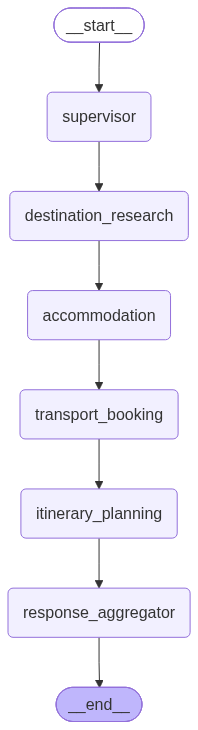

In [ ]:
from IPython.display import Image, display

# Assuming 'app' is your compiled graph
display(Image(travel_graph.get_graph().draw_mermaid_png()))


# Execution

In [ ]:
def run_travel_multiagent(user_request: str):
  initial_state= {
      "user_request": user_request,
      "messages": [HumanMessage(content= user_request)]
  }
  result= travel_graph.invoke(initial_state, config= {"recursion_limit": 20})
  return result

In [ ]:
request= """
Plan a 4-day trip from kolkata to hyderabad from 2026-09-11 to 2026-09-15 for 2 adults. Budget is medium. We like temples, cafes, local food and iconic landmark.
Need flight options, hotel suggestions, a day-wise itinerary, local transport guidance and cab fare details for airport transport. Also give me approx budget
for the tour.
"""

result= run_travel_multiagent(request)

Planner attempt 1/5 using openai/gpt-oss-20b
LLM attempt 1/5 using openai/gpt-oss-20b
LLM attempt 1/5 using openai/gpt-oss-20b
LLM attempt 1/5 using openai/gpt-oss-20b
LLM attempt 1/5 using openai/gpt-oss-20b
LLM attempt 1/5 using openai/gpt-oss-20b


In [ ]:
print(result.get("final_response", ""))

**4‑Day Kolkata → Hyderabad Trip (11 – 15 Sep 2026)**  
*2 adults, medium‑budget, interests: temples, cafés, local food, iconic landmarks.*

---

## 1. Trip Summary  
| Item | Detail |
|------|--------|
| Dates | 11 Sep 2026 – 15 Sep 2026 |
| Duration | 4 nights / 5 days |
| Travelers | 2 adults |
| Budget | Medium (~₹90 k total) |
| Highlights | Charminar, Golconda Fort, Birla Mandir, Hussain Sagar Lake, cafés, local street food |

---

## 2. Destination Insights  
- **Climate** – 29–30 °C, low humidity, occasional evening showers. Pack light cotton, hat, sunglasses, and a light rain‑coat.  
- **Transport** – Airport‑to‑city: ₹200–₹300 via app‑cab, ₹350 via airport taxi. City: auto‑rickshaws ₹10–15/km, app‑cabs ₹8–12/km, metro ₹10–30 fare.  
- **Currency** – INR. ATMs everywhere; credit cards accepted in hotels & cafés.  
- **Safety** – Keep valuables in hotel safe; avoid isolated areas after dark.  
- **Connectivity** – Buy a local SIM (Airtel/Jio) for data and calls.  
- **Tipping**